In [1]:
import os
os.chdir("../")
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from burgers.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

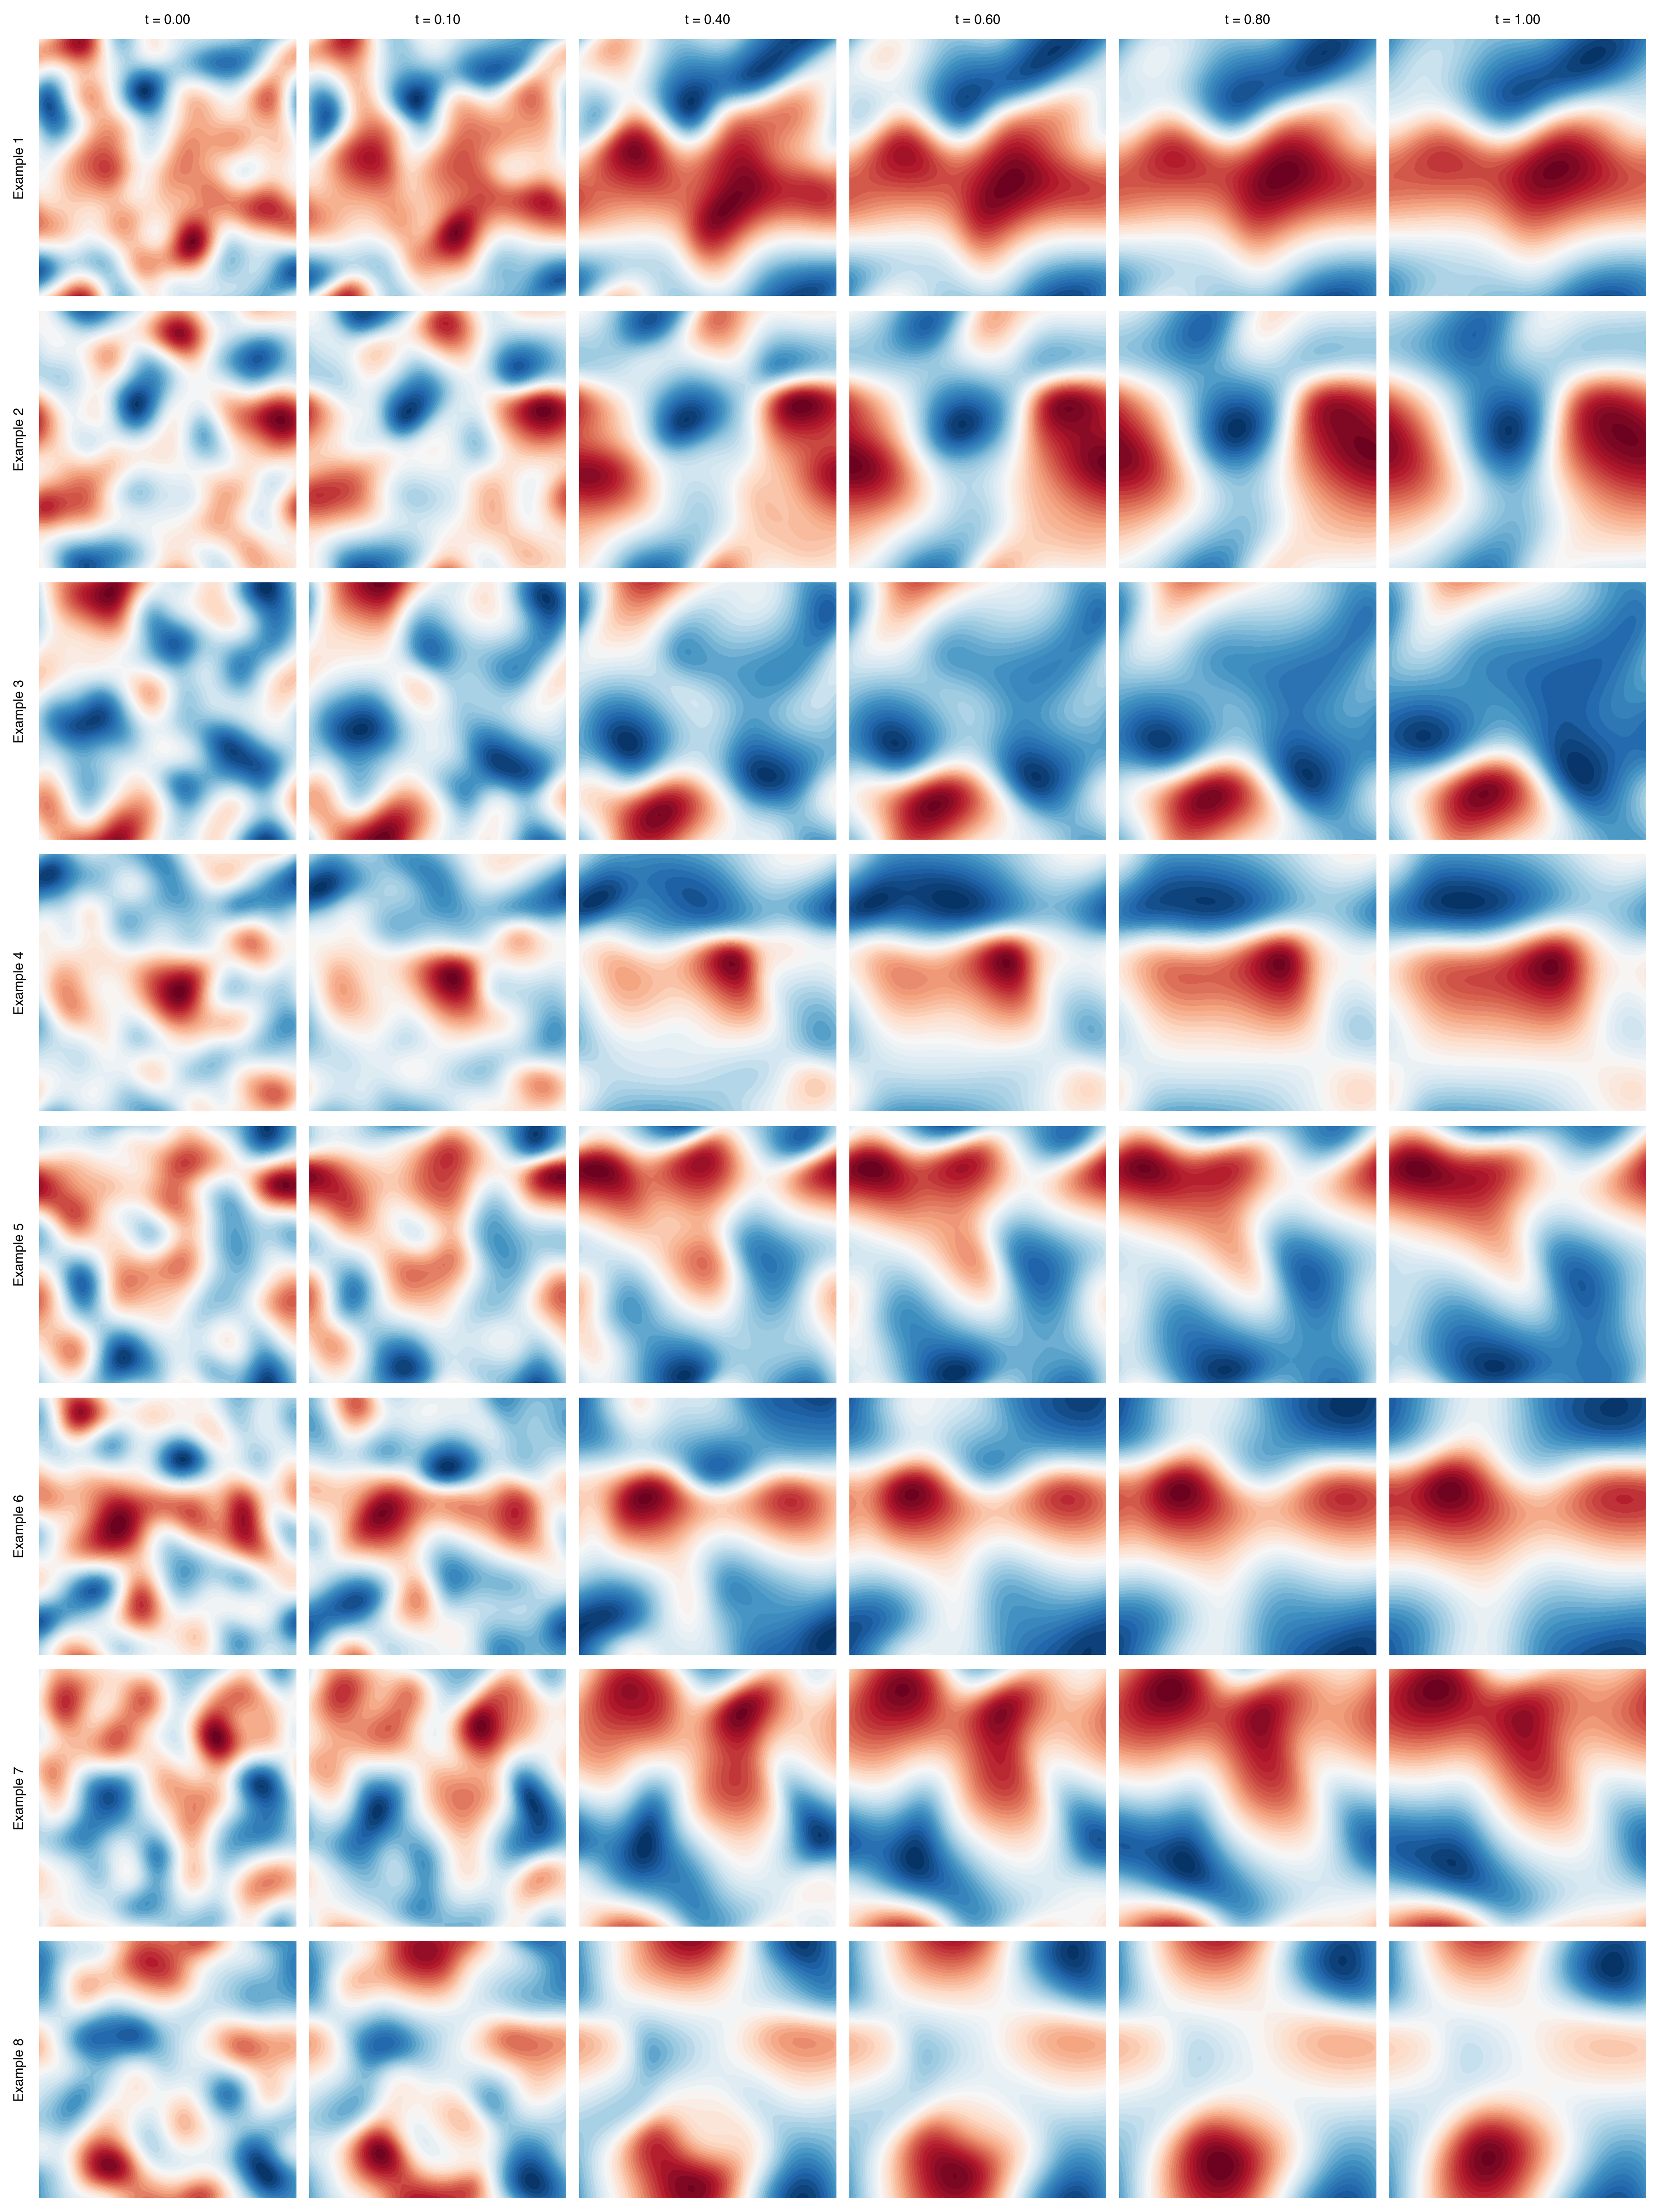

In [3]:
data = jnp.load("data/burgers/burgers_solutions.npz")
x = data["x"]
y = data["y"]
t = data["times"]
solutions = data["solutions"]  # (num_times, num_points)
xx, yy = jnp.meshgrid(x, y, indexing="xy") # (H, W)


time_idxs = [0, 1, 4, 6, 8, 10]
fig, axes = plt.subplots(8, 6, figsize=(12, 16), sharex=True, sharey=True)
for example_id in range(8):
    for i, time_idx in enumerate(time_idxs):
        ax = axes[example_id, i]
        ax.contourf(xx, yy, solutions[example_id, time_idx, 1], levels=50, cmap="RdBu_r")
        if example_id == 0:
            # ax.set_title(f"t = {t[time_idx]:.2f}", pad=5)
            ax.text(0.5, 1.05, f"t = {t[time_idx]:.2f}", va="bottom", ha="center", transform=ax.transAxes)
        if i == 0:
            # ax.set_ylabel(f"Example {example_id + 1}", rotation=0, labelpad=15)
            ax.text(-0.05, 0.5, f"Example {example_id + 1}", va="center", ha="right", rotation=90, transform=ax.transAxes)
        ax.set_axis_off()
        ax.set_aspect("equal")
fig.tight_layout()

In [4]:
from burgers.periodic_cvit import PeriodicCViT

key = jax.random.PRNGKey(0)
model_params = configs.model_params
model_skeleton = PeriodicCViT(
    key,
    lx=configs.lx,
    ly=configs.ly,
    **model_params,
)

weight = "/root/autodl-tmp/tf-logs/burgers/cvit/emb_dim512-2gpu/model_epoch_7000.eqx"
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [9]:
data_dir = configs.data_dir
# target_ts = configs.target_ts
target_ts =[0.0, 0.1, 0.3, 0.6, 1.0]
Lc = configs.Lc
Tc = configs.Tc
data = jnp.load(f"{data_dir}/burgers_solutions.npz")
x = data["x"]  # (W,)
y = data["y"]  # (H,)
fft_times = data["times"]  # (T,)
ref_sols = data["solutions"]    
idxs = jnp.array(
    [jnp.argmin(jnp.abs(fft_times - t)) for t in target_ts]
)
ref_sols = ref_sols[:, idxs, ...] # B, T, C, H, W

B, T, C, H, W = ref_sols.shape
us = ref_sols[:, 0, ...] # B, C=2, H, W
xx, yy = jnp.meshgrid(x, y, indexing="xy")  # (H, W)
xx = xx / Lc
yy = yy / Lc
x_pde = jnp.stack([
    xx.reshape(-1),
    yy.reshape(-1),
], axis=-1)  # (Nx*Ny, 2)

def fwd_fn(carry, t):
    t_pde = jnp.full((x_pde.shape[0], 1), t)
    sol = jax.vmap(
        model, in_axes=(0, None, None)
    )(
        us, x_pde, t_pde
    ) # B, Nx*Ny, C
    return carry, sol

_, sols = jax.lax.scan(
    fwd_fn,
    None,
    jnp.array(target_ts) / Tc,
) # sols: T, B, H*W, C=2

sols = rearrange(
    sols, "t b (h w) c -> b t c h w", h=int(H), w=int(W)
)

Text(0.5, 1.02, 'Exam. 1, Var. u, Rel. L2 Error: 1.22e-01')

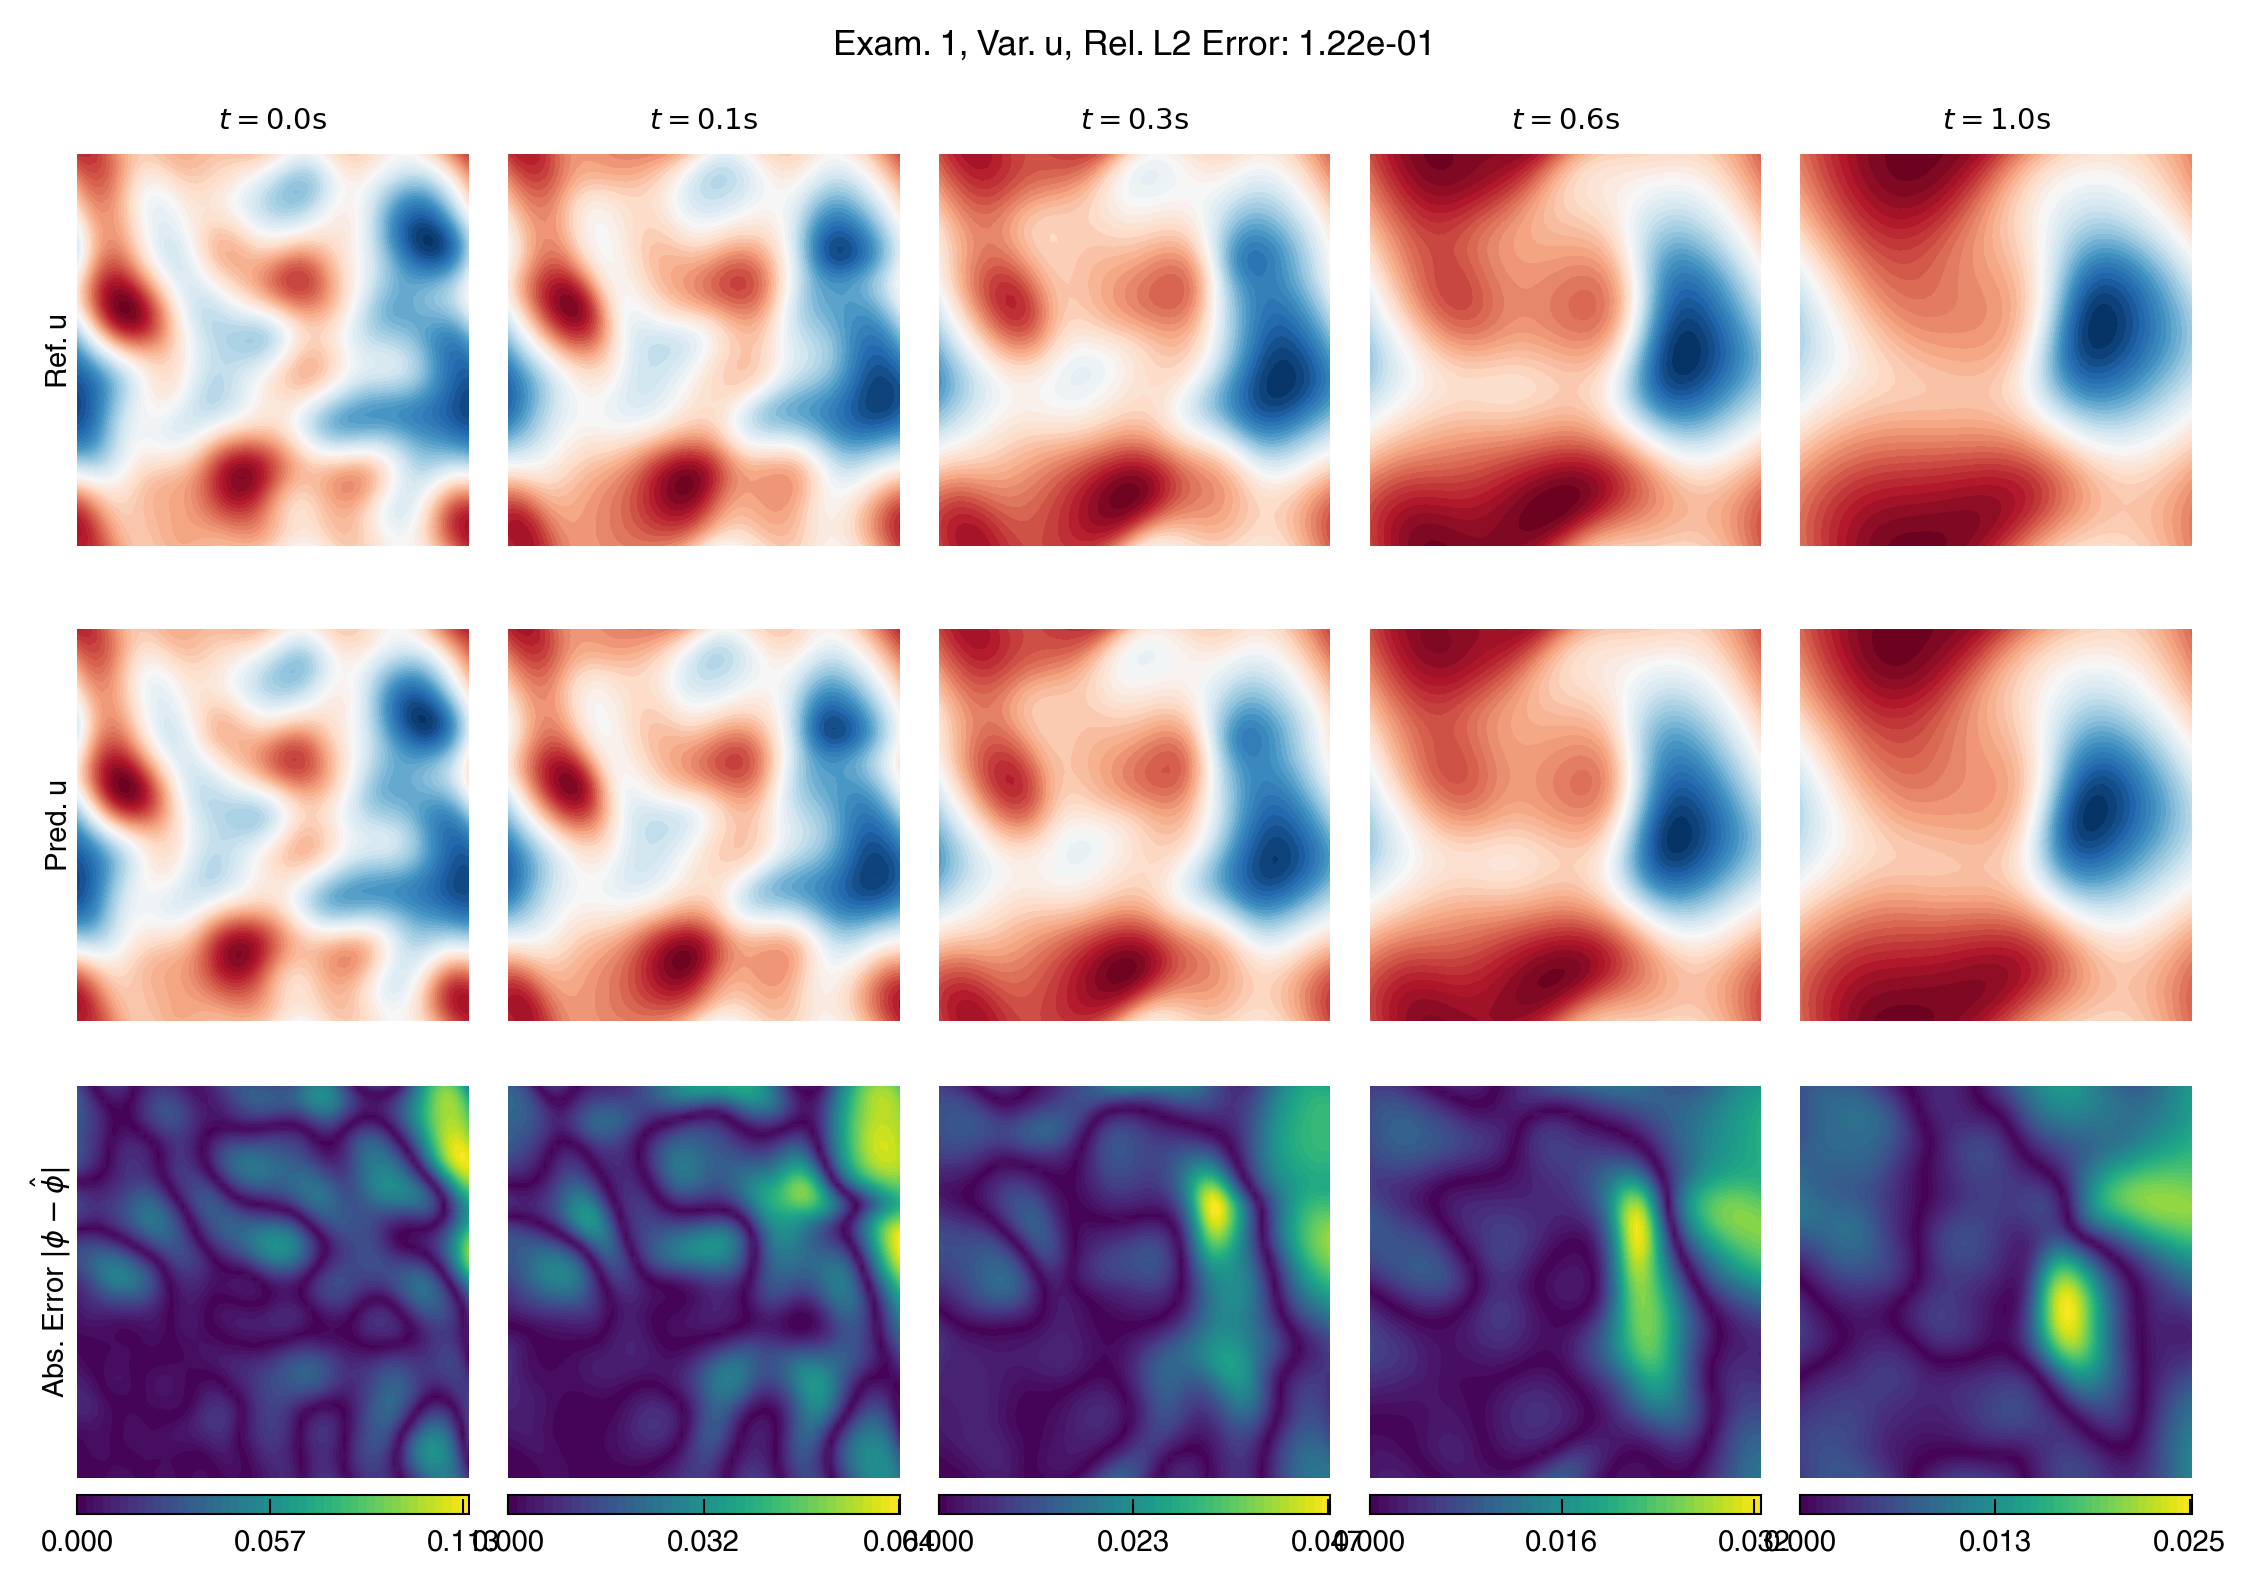

In [10]:
batch_th = 1
channel_th = 0  # 0: u, 1: v
fig, axes = plt.subplots(
    3,
    len(target_ts),
    figsize=(1.5 * len(target_ts), 5),
    subplot_kw={
        "aspect": "equal",
    },
)
notation = "u" if channel_th == 0 else "v"
for i, tic in enumerate(target_ts):
    ax = axes[0, i]
    ax.set_axis_off()
    ax.contourf(
        xx, yy,
        ref_sols[batch_th, i, channel_th, :, :],
        levels=50,
        cmap="RdBu_r",
    )
    if i == 0:
        ax.text(
            -0.01,
            0.5,
            f"Ref. {notation}",
            rotation=90,
            va="center",
            ha="right",
            transform=ax.transAxes,
        )
    ax.text(
        0.5,
        1.05,
        rf"$t={tic:.1f}\mathrm{{s}}$",
        va="bottom",
        ha="center",
        transform=ax.transAxes,
    )
    


    ax = axes[1, i]
    ax.set_axis_off() 
    pred_cont = ax.contourf(
        xx, yy,
        sols[batch_th, i, channel_th, :, :],
        levels=50,
        cmap="RdBu_r",
    )
    if i == 0:
        ax.text(
            -0.01,
            0.5,
            f"Pred. {notation}",
            rotation=90,
            va="center",
            ha="right",
            transform=ax.transAxes,
        )
        

    
    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(
        ref_sols[batch_th, i, channel_th, :, :]
        - sols[batch_th, i, channel_th, :, :]
    )
    diff_cont = ax.contourf(
        xx, yy,
        diff,
        levels=50,
        cmap="viridis",
    )
    
    if i == 0:
        ax.text(
            -0.01,
            0.5,
            r"Abs. Error $|\phi - \hat{\phi}|$",
            rotation=90,
            va="center",
            ha="right",
            transform=ax.transAxes,
        )
        
    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.3f", ticks=jnp.linspace(0, jnp.max(diff), num=3)
    )
    total_l2 = jnp.sqrt(jnp.sum((ref_sols - sols) ** 2, axis=(1, 3, 4))) / jnp.sqrt(
        jnp.sum(ref_sols**2, axis=(1, 3, 4))
    )
    total_l2 = jnp.mean(total_l2)
    fig.subplots_adjust(
        left=0.03, right=0.97, top=0.95, bottom=0.03, hspace=0.1, wspace=0.1
    )
fig.suptitle(
    f"Exam. {batch_th}, Var. {notation}, Rel. L2 Error: {total_l2:.2e}",
    y=1.02,
)